In [33]:
import json
import mlx.core as mx
import mlx.nn as nn
import mlx.optimizers as optim

In [34]:
with open("common_vocab_corpus.txt", "r") as f:
    text = f.read()

tokens = text.lower().replace("(", "").replace(")", "").split()
vocab = sorted(set(tokens))
vocab_size = len(vocab)
print(vocab[:5])
word_to_id = {word: i for i, word in enumerate(vocab)}
id_to_word = {i: word for word, i in word_to_id.items()}
encoded = [word_to_id[word] for word in tokens]
print(encoded[:5])
center_ids = mx.array([pair[0] for pair in training_pairs])
context_ids = mx.array([pair[1] for pair in training_pairs])


['a', 'about', 'across', 'adult', 'after']
[305, 220, 333, 313, 305]


In [35]:
window_size = 2
training_pairs = []

for center_index in range(len(encoded)):
    center_word_id = encoded[center_index]
    start = max(0, center_index - window_size)
    end = min(len(encoded), center_index + window_size + 1)

    for context_index in range(start, end):
        if context_index != center_index:
            context_word_id = encoded[context_index]
            training_pairs.append((center_word_id, context_word_id))

# for ['a', 'about', 'across', 'adult', 'after']
# center is 'across'
# training pairs:
# a across
# about across
# adult across
# after across
print(f"Training Pairs ({training_pairs.__len__()}):")
print(training_pairs[:5])
center_ids = mx.array([pair[0] for pair in training_pairs])
context_ids = mx.array([pair[1] for pair in training_pairs])



Training Pairs (5174):
[(305, 220), (305, 333), (220, 305), (220, 333), (220, 313)]


In [36]:
class WordEmbeddingModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.output = nn.Linear(embedding_dim, vocab_size)

    def __call__(self, word_ids):
        vectors = self.embedding(word_ids)
        logits = self.output(vectors)
        return logits



In [37]:
embedding_dim=8
model = WordEmbeddingModel(vocab_size, embedding_dim)
def loss_fn(model, center_ids, context_ids):
    logits = model(center_ids)
    loss = nn.losses.cross_entropy(logits, context_ids, reduction="mean")
    return loss

optimizer = optim.Adam(learning_rate=0.05)
loss_and_grad_fn = nn.value_and_grad(model, loss_fn)


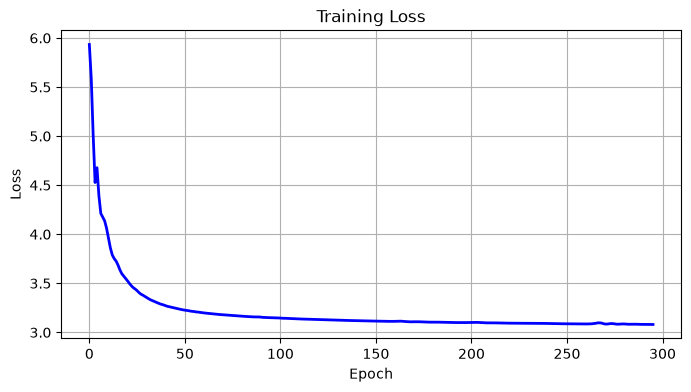

In [38]:
import matplotlib.pyplot as plt
epochs = 300
losses = []

from IPython.display import clear_output, display

epochs = 300
losses = []

fig, ax = plt.subplots(figsize=(8, 4))

for epoch in range(epochs):
    loss, grads = loss_and_grad_fn(model, center_ids, context_ids)

    optimizer.update(model, grads)
    mx.eval(loss, model.parameters(), optimizer.state)

    loss_value = float(loss.item())
    losses.append(loss_value)

    if epoch % 5 == 0:
        clear_output(wait=True)

        ax.clear()
        ax.plot(losses, color="blue", linewidth=2)
        ax.set_title("Training Loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(True)

        display(fig)

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, loss: {loss_value:.4f}")


plt.close(fig)
model.save_weights("embedding_model.safetensors")

In [43]:
embeddings = model.embedding.weight
def cosine_similarity(a, b):
    a_norm = a / mx.sqrt(mx.sum(a * a))
    b_norm = b / mx.sqrt(mx.sum(b * b, axis=1, keepdims=True))
    return mx.sum(a_norm * b_norm, axis=1)

def most_similar(word, top_k=5):
    if word not in word_to_id:
        print(f"'{word}' is not in vocab")
        return

    word_id = word_to_id[word]
    word_vector = embeddings[word_id]

    similarities = cosine_similarity(word_vector, embeddings)

    sorted_ids = mx.argsort(-similarities)

    for idx in sorted_ids[:top_k + 1]:
        idx = idx.item()
        other_word = id_to_word[idx]
        score = similarities[idx].item()

        if other_word == word:
            continue

        print(other_word, round(score, 4))

def similarity(word1, word2):
    if word1 not in word_to_id:
        print(f"'{word1}' is not in vocab")
        return

    if word2 not in word_to_id:
        print(f"'{word2}' is not in vocab")
        return

    id1 = word_to_id[word1]
    id2 = word_to_id[word2]

    vector1 = embeddings[id1]
    vector2 = embeddings[id2]

    score = mx.sum(vector1 * vector2) / (
        mx.sqrt(mx.sum(vector1 * vector1)) *
        mx.sqrt(mx.sum(vector2 * vector2))
    )

    return score.item()


In [44]:
most_similar("cat", top_k=5)

green 0.8898
calm 0.8852
sleeps 0.8758
noise 0.8644
looks 0.8638


In [47]:
print("Cat-Dog:", similarity("cat", "dog"))
print("Cat-Looks:", similarity("cat", "looks"))


Cat-Dog: 0.7387915849685669
Cat-Looks: 0.8638349175453186
